In [75]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

from pydantic import BaseModel,Field

from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv


from tavily import TavilyClient

from typing import TypedDict,Literal

load_dotenv()
model = ChatOpenAI(model = 'gpt-4o-mini')
embeddings = OpenAIEmbeddings(model = 'text-embedding-3-small')

In [76]:
docs = PyPDFLoader(r"D:\LangGraph_Revision_Material\demo_company_policy_docs.pdf").load()

In [77]:
chunked_docs = RecursiveCharacterTextSplitter(chunk_size = 600,chunk_overlap = 150).split_documents(docs)

In [78]:

vector_store = Chroma(
    collection_name="numpy",
    embedding_function=embeddings,
    persist_directory="./chroma_langchain_db",  
)
# vector_store.add_documents(chunked_docs)


In [79]:
retriever = vector_store.as_retriever(kwargs={'k':4})

In [80]:
len(vector_store.get()['ids'])

10

In [81]:
class state(TypedDict):
    query: str
    
    need_retrieve : bool
    retrieved_docs : list[Document]
    
    good_docs : list[Document]
    context : str
    
    issup_tries : int
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: list[str]
    
    isuse: Literal["useful", "not_useful"]
    use_reason: str
    
    rewrite_tries : int
    retrieval_query : str
    
    answer : str
    

In [82]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

    
decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON with key: should_retrieve (boolean).\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts from company documents.\n"
            "- should_retrieve=False for general explanations/definitions.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

def need_retrieval(state:state):
    query = state['query']
    chain = decide_retrieval_prompt | model.with_structured_output(RetrieveDecision)
    resp = chain.invoke({'question':query})
    # print(resp.should_retrieve)
    return {'need_retrieve':resp.should_retrieve}

def need_retrieval_route(state:state) -> Literal['generate_direct','retrieve']:
    return 'generate_direct' if state['need_retrieve'] == False else 'retrieve'
    

In [83]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer using only your general knowledge.\n"
            "If it requires specific company info, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)
def generate_direct(state:state):
    query = state['query']
    chain = direct_generation_prompt | model
    resp = chain.invoke({'question':query}).content
    return {'answer':resp}

In [84]:
def retrieve(state:state):
    retrieved_docs = retriever.invoke(state.get("retrieval_query") or state["query"])
    return{'retrieved_docs':retrieved_docs}
    

In [85]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True ONLY if the document contains info that can directly answer the question."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance at a TOPIC level.\n"
            "Return JSON matching the schema.\n\n"
            "A document is relevant if it discusses the same entity or topic area as the question.\n"
            "It does NOT need to contain the exact answer.\n\n"
            "Examples:\n"
            "- HR policies are relevant to questions about notice period, probation, termination, benefits.\n"
            "- Pricing documents are relevant to questions about refunds, trials, billing terms.\n"
            "- Company profile is relevant to questions about leadership, culture, size, or strategy.\n\n"
            "Do NOT decide whether the document fully answers the question.\n"
            "That will be checked later by IsSUP.\n"
            "When unsure, return is_relevant=true."
        ),
        ("human", "Question:\n{question}\n\nDocument:\n{document}"),
    ]
)

def is_relevant(state:state):
    docs = state['retrieved_docs']
    chain = is_relevant_prompt | model.with_structured_output(RelevanceDecision)
    good_docs = []
    
    for doc in docs:
        resp = chain.invoke({'question':state['query'],'document':doc}).is_relevant
        if resp:
            good_docs.append(doc)
            
    return {'good_docs':good_docs}

def relevency_route(state:state) -> Literal['no_ans_found','generate_from_context']:
    return 'generate_from_context' if len(state.get('good_docs',[])) > 0 else 'no_ans_found'
    

In [86]:
def no_ans_found(state:state):
    return {'answer':'No answer found'}

In [87]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business rag chatbot.\n\n"
            "You will receive a CONTEXT block from internal company documents.\n"
            "Task:\n"
            "Answer the question based on the context"
            "Dont mention that you are getting a context in your answer"
        ),
        ("human", "Question:\n{question}\n\nContext:\n{context}"),
    ]
)
def generate_from_context(state:state):
    query = state['query'] 
    context = "\n".join(doc.page_content for doc in state['good_docs'])
    
    chain = rag_generation_prompt | model
    resp = chain.invoke({'question':query,'context':context}).content
    return {'answer':resp,'context':context}

In [88]:
class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: list[str] = Field(default_factory=list)

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

def is_sup(state:state):
    
    context = state['context']
    query = state['query']
    answer = state['answer']
    
    chain = issup_prompt | model.with_structured_output(IsSUPDecision)
    resp = chain.invoke({'context':context,'question':query,'answer':answer})
    
    return {'issup':resp.issup,'evidence':resp.evidence}

MAX_ISSUP_TRIES = 5

def is_sup_route(state:state)->Literal['is_use','revise_answer']:
    issup = state['issup']
    
    if issup == 'fully_supported' or state.get('issup_tries',0) >= MAX_ISSUP_TRIES:
        return 'is_use'
    else:
        return 'revise_answer'


In [89]:
class IsUSEDecision(BaseModel):
    isuse: Literal["useful", "not_useful"]
    reason: str = Field(..., description="Short reason in 1 line.")

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)

def is_use(state:state):
    chain = isuse_prompt | model.with_structured_output(IsUSEDecision)
    
    resp = chain.invoke({'question':state['query'],'answer':state['answer']})
    return {"isuse": resp.isuse, "use_reason": resp.reason}

MAX_REWRITE_TRIES = 5

def use_route(state:state)->Literal["END",'rewrite_question','no_answer_found']:
    if state['isuse'] == 'useful':
        return "END"
    if state.get("rewrite_tries", 0) >= MAX_REWRITE_TRIES:
        return "no_answer_found"

    return "rewrite_question"
    

In [90]:
class RewriteDecision(BaseModel):
    retrieval_query: str = Field(
        ...,
        description="Rewritten query optimized for vector retrieval against internal company PDFs."
    )

rewrite_for_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6–16 words).\n"
            "- Preserve key entities (e.g., NexaAI, plan names).\n"
            "- Add 2–5 high-signal keywords that likely appear in policy/pricing docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output JSON with key: retrieval_query\n\n"
            "Examples:\n"
            "Q: 'Do NexaAI plans include a free trial?'\n"
            "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
            "Q: 'What is NexaAI refund policy?'\n"
            "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
    ]
)




def rewrite_question(state: state):
    chain = rewrite_for_retrieval_prompt | model.with_structured_output(RewriteDecision)
    decision = chain.invoke({'question':state['query'],'retrieval_query':state.get("retrieval_query", ""),'answer':state["answer"]})

    return {
        "retrieval_query": decision.retrieval_query,
        "rewrite_tries": state.get("rewrite_tries", 0) + 1
    }

In [91]:
revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)


def revise_answer(state:state):
    chain = revise_prompt | model
    resp = chain.invoke({'question':state["query"],'answer':state.get("answer", ""),'context':state.get("context", "")}).content
    return {
        "answer": resp,
        "retries": state.get("issup_tries", 0) + 1
    }

In [92]:
graph = StateGraph(state)

graph.add_node('need_retrieval',need_retrieval)
graph.add_node('generate_direct',generate_direct)
graph.add_node('retrieve',retrieve)
graph.add_node('is_relevant',is_relevant)
graph.add_node('no_ans_found',no_ans_found)
graph.add_node('generate_from_context',generate_from_context)
graph.add_node('is_supported',is_sup)
graph.add_node('is_use',is_use)
graph.add_node('revise_answer',revise_answer)
graph.add_node('rewrite_question',rewrite_question)


graph.add_edge(START,"need_retrieval")
graph.add_conditional_edges('need_retrieval',need_retrieval_route)
graph.add_edge('generate_direct',END)
graph.add_edge('retrieve','is_relevant')
graph.add_conditional_edges('is_relevant',relevency_route)
graph.add_edge('generate_from_context','is_supported')

graph.add_conditional_edges('is_supported',is_sup_route)
graph.add_edge('revise_answer','is_supported')
graph.add_conditional_edges('is_use',use_route,{
        "END": END,
        "rewrite_question": "rewrite_question",
        "no_answer_found": "no_ans_found",
    })
graph.add_edge('rewrite_question','retrieve')
graph.add_edge('no_ans_found',END)



workflow = graph.compile()


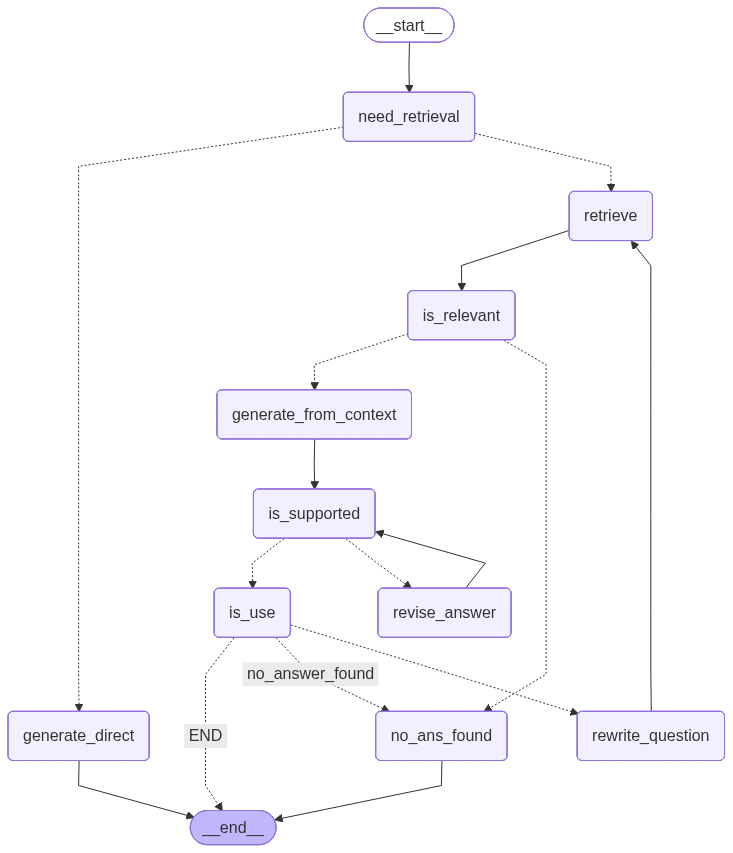

In [93]:
workflow

In [96]:
res = workflow.invoke({'query':'Can employees work fully remote permanently?'})

In [97]:
res

{'query': 'Can employees work fully remote permanently?',
 'need_retrieve': True,
 'retrieved_docs': [Document(id='29cb1c15-cf22-42d9-bc7f-5e347e41de8c', metadata={'keywords': '', 'trapped': '/False', 'creator': '(unspecified)', 'moddate': '2026-05-15T14:13:33+00:00', 'total_pages': 2, 'producer': 'ReportLab PDF Library - www.reportlab.com', 'page': 0, 'source': 'D:\\LangGraph_Revision_Material\\demo_company_policy_docs.pdf', 'author': '(anonymous)', 'title': '(anonymous)', 'subject': '(unspecified)', 'page_label': '1', 'creationdate': '2026-05-15T14:13:33+00:00'}, page_content='1. Remote Work Policy\nEmployees may work remotely up to three days per week with manager approval. Core collaboration hours are 10:00\nAM to 3:00 PM local time. Employees handling customer data must use company-managed devices and VPN access\nat all times. Remote employees are expected to respond to internal Slack messages within two business hours. The\nIT department performs quarterly endpoint security audit